Практическая работа 15: Тематическое моделирование текстов вакансий
Загружен jobs.csv, размер: (11097, 11)
Столбец с описанием: description

В датасете нет столбца с названиями профессий.

Отобрано 112 вакансий, содержащих 'python'

Пример предобработанного текста:
отдел анализ проект приглашать аналитика данные команда изобретать новый услуга нуль создание cvp услуга открытие новый магазин смочь поучаствовать процесс ценообразование подбор ассортимент формирование операционный экономический модель магазин твой задача написание sqlзапрос формирование отчёт ана...
Матрица признаков: (112, 1000) (документов × n-грамм)

Тематическое моделирование LDA (k=5 тем)...

Темы LDA (топ-12 n-грамм):
Тема 1: разработка, тестирование, проект, команда, система, решение, понимание, уровень, задача, участие, продукт, новый
Тема 2: система, сетевой, администрирование, linux, инцидент, мониторинг, безопасность, настройка, инфраструктура, технический, поддержка, сеть
Тема 3: система, data, информационный,

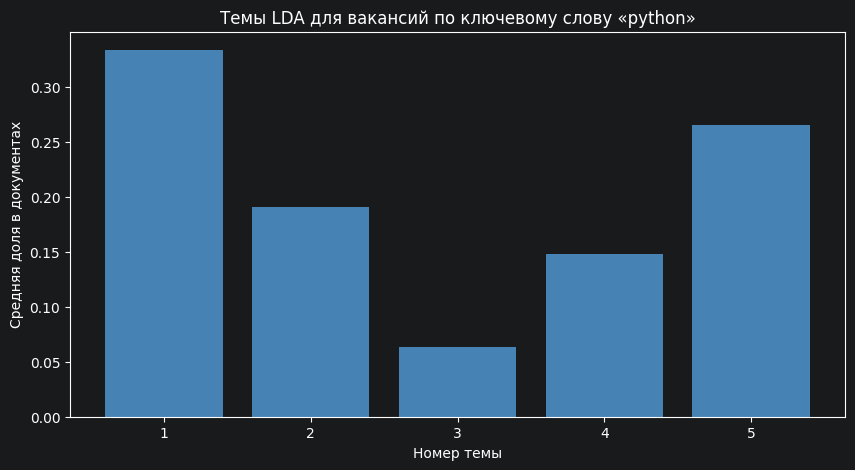

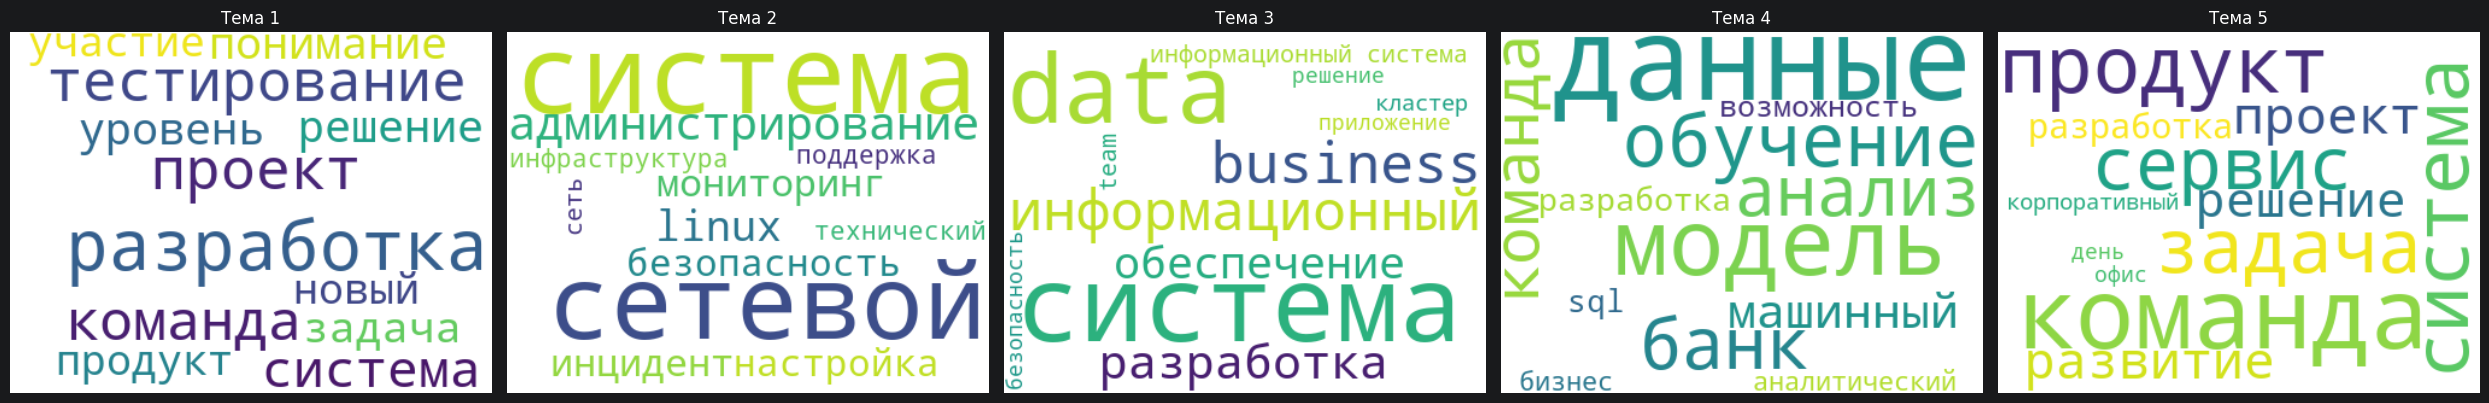


ИНТЕРПРЕТАЦИЯ ТЕМ И ВЫВОДЫ
Анализ проведён для вакансий с ключевым словом «python»
Всего обработано 112 описаний. Использованы n-граммы (1-3 слова).

Тема 1: Веб-разработка, бэкенд
   Ключевые слова: разработка, тестирование, проект, команда, система

Тема 2: Смешанные навыки
   Ключевые слова: система, сетевой, администрирование, linux, инцидент

Тема 3: Веб-разработка, бэкенд
   Ключевые слова: система, data, информационный, business, разработка

Тема 4: Анализ данных, SQL, визуализация
   Ключевые слова: данные, модель, обучение, банк, анализ

Тема 5: Смешанные навыки
   Ключевые слова: команда, продукт, система, задача, сервис



In [9]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

# ------------------------- 1. НАСТРОЙКА -------------------------
def download_nltk_resources():
    resources = ['punkt', 'punkt_tab', 'stopwords']
    for res in resources:
        try:
            if res == 'stopwords':
                nltk.data.find(f'corpora/{res}')
            else:
                nltk.data.find(f'tokenizers/{res}')
        except LookupError:
            print(f"Скачивание ресурса NLTK: {res}")
            nltk.download(res, quiet=True)

download_nltk_resources()
morph = pymorphy3.MorphAnalyzer()

# Стоп-слова
stop_words_ru = set(stopwords.words('russian'))
extra_stop_words = {
    'работа', 'вакансия', 'компания', 'должность', 'сотрудник', 'кандидат',
    'обязанности', 'требования', 'условия', 'навыки', 'опыт', 'знание', 'умение',
    'работать', 'быть', 'мочь', 'делать', 'также', 'более', 'менее', 'очень',
    'например', 'который', 'этот', 'свой', 'ваш', 'наш', 'год', 'человек',
    'можно', 'нужно', 'являться', 'становиться', 'иметь', 'находиться',
    'пользоваться', 'использовать', 'обладать'
}
stop_words_ru.update(extra_stop_words)
stop_words_en = set(stopwords.words('english'))
STOP_WORDS = stop_words_ru.union(stop_words_en)

print("="*70)
print("Практическая работа 15: Тематическое моделирование текстов вакансий")
print("="*70)

# ------------------------- 2. ЗАГРУЗКА ДАННЫХ -------------------------
file_path = 'jobs.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Загружен {file_path}, размер: {df.shape}")
    if 'description' in df.columns:
        desc_col = 'description'
    else:
        desc_col = df.columns[1]
    print(f"Столбец с описанием: {desc_col}")
except FileNotFoundError:
    print(f"Файл {file_path} не найден. Создаю пример.")
    df = pd.DataFrame({
        'description': [
            'Анализ данных, SQL, Python, дашборды Tableau',
            'Разработка на Python, Django, REST API',
            'ETL-пайплайны, Spark, Hadoop, ClickHouse'
        ]
    })
    desc_col = 'description'

# Фильтр по ключевому слову (т.к. нет колонки профессий)
print("\nВ датасете нет столбца с названиями профессий.")
keyword = input("Введите ключевое слово для фильтрации (например, 'python', 'аналитик', 'data')\n"
                "или оставьте пустым для анализа всех вакансий: ").strip()

if keyword:
    mask = df[desc_col].astype(str).str.lower().str.contains(keyword.lower(), na=False)
    df_filtered = df[mask].copy()
    print(f"\nОтобрано {len(df_filtered)} вакансий, содержащих '{keyword}'")
else:
    df_filtered = df.copy()
    print(f"\nАнализируем все {len(df_filtered)} вакансий (без фильтра)")

if len(df_filtered) == 0:
    print("Нет подходящих вакансий. Завершение.")
    exit(1)

# ------------------------- 3. ПРЕДОБРАБОТКА ТЕКСТА -------------------------
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zа-яё\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def lemmatize_and_filter(tokens):
    result = []
    for token in tokens:
        if len(token) < 3:
            continue
        parsed = morph.parse(token)[0]
        lemma = parsed.normal_form
        if len(lemma) >= 3 and lemma not in STOP_WORDS:
            result.append(lemma)
    return result

def preprocess_docs(docs):
    processed = []
    for text in docs:
        clean = clean_text(text)
        tokens = word_tokenize(clean, language='russian')
        lemmas = lemmatize_and_filter(tokens)
        processed.append(' '.join(lemmas))
    return processed

raw_texts = df_filtered[desc_col].astype(str).tolist()
processed_docs = preprocess_docs(raw_texts)
print(f"\nПример предобработанного текста:\n{processed_docs[0][:300]}...")

# ------------------------- 4. N-ГРАММЫ И LDA -------------------------
vectorizer = CountVectorizer(
    ngram_range=(1, 3),
    max_df=0.8,
    min_df=2,
    max_features=1000
)
X = vectorizer.fit_transform(processed_docs)
feature_names = vectorizer.get_feature_names_out()
print(f"Матрица признаков: {X.shape} (документов × n-грамм)")

# Количество тем (не больше 5 или меньше 2)
n_topics = min(5, max(2, len(processed_docs)//5)) if len(processed_docs) > 5 else 2
print(f"\nТематическое моделирование LDA (k={n_topics} тем)...")
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(X)

# Вывод топ-слов по темам
print("\nТемы LDA (топ-12 n-грамм):")
for topic_idx, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[:-13:-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f"Тема {topic_idx+1}: {', '.join(top_words)}")

# Распределение документов
doc_topic = lda.transform(X)
dominant = doc_topic.argmax(axis=1)
print(f"\nРаспределение документов по темам: {Counter(dominant)}")

# Визуализация важности тем
plt.figure(figsize=(10,5))
plt.bar(range(1, n_topics+1), doc_topic.mean(axis=0), color='steelblue')
plt.xlabel('Номер темы')
plt.ylabel('Средняя доля в документах')
plt.title(f'Темы LDA{f" для вакансий по ключевому слову «{keyword}»" if keyword else ""}')
plt.xticks(range(1, n_topics+1))
plt.show()

# Облака слов для каждой темы
fig, axes = plt.subplots(1, n_topics, figsize=(5*n_topics, 4))
if n_topics == 1:
    axes = [axes]
for i in range(n_topics):
    topic_vec = lda.components_[i]
    top_indices = topic_vec.argsort()[:-13:-1]
    word_freq = {feature_names[idx]: topic_vec[idx] for idx in top_indices}
    wc = WordCloud(width=400, height=300, background_color='white', colormap='viridis').generate_from_frequencies(word_freq)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Тема {i+1}')
plt.tight_layout()
plt.show()

# ------------------------- 5. ИНТЕРПРЕТАЦИЯ И ВЫВОДЫ -------------------------
print("\n" + "="*70)
print("ИНТЕРПРЕТАЦИЯ ТЕМ И ВЫВОДЫ")
print("="*70)
print(f"Анализ проведён для {'всех вакансий' if not keyword else f'вакансий с ключевым словом «{keyword}»'}")
print(f"Всего обработано {len(processed_docs)} описаний. Использованы n-граммы (1-3 слова).\n")

for i, topic in enumerate(lda.components_):
    top5 = [feature_names[j] for j in topic.argsort()[:-6:-1]]
    if any(w in ['анализ', 'данные', 'sql', 'pandas', 'дашборд'] for w in top5):
        desc = "Анализ данных, SQL, визуализация"
    elif any(w in ['разработка', 'django', 'flask', 'java', 'spring'] for w in top5):
        desc = "Веб-разработка, бэкенд"
    elif any(w in ['etl', 'spark', 'hadoop', 'clickhouse'] for w in top5):
        desc = "Инженерия данных, ETL, большие данные"
    elif any(w in ['отчет', 'excel', 'power bi'] for w in top5):
        desc = "Бизнес-отчетность, BI"
    else:
        desc = "Смешанные навыки"
    print(f"Тема {i+1}: {desc}")
    print(f"   Ключевые слова: {', '.join(top5)}\n")
